In [1]:
import numpy as np
import pandas as pd
import xarray as xr
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
from pathlib import Path
import sys

# Go up one level from doomsday/ to habitability/
sys.path.insert(0, str(Path.cwd().parent))
from calculator import SeaIceCalc, Habitability, SST, SRD, Tempdiff, Tempdiffall
from timeseries_calc import OceanParam, WholeGlobeParam, LandParam, SeaIce

In [2]:
file = "../../solarflux/stability/run_1.25_5yr/output_daily.nc"
ds = xr.open_dataset(file)
ds_crop = ds.sel(time=slice("2003-01-01", "2003-12-31"))
times = ds_crop.time.dt.dayofyear.values

In [3]:
# Compare with Earth

months_to_keep = [3,6,9,12]

file_earth = "../../earth/output.nc"
earth_data = xr.open_dataset(file_earth)
earth_crop = earth_data.sel(time=slice("2003-01-01", "2003-12-31"))

file_snow = "../../solarflux/stability/run_0.1_5yr/output.nc"
ds_snow = xr.open_dataset(file_snow)
snow_crop = ds_snow.sel(time=slice("2003-01-01", "2004-01-01"))

# Functions that return a scalar for a given monthly dataset
def layer_temp_mean(ds, layer_idx):
    return WholeGlobeParam.globalparam_timeseries(ds["temp"].isel(layer=layer_idx)).mean()

def tsurf_mean(ds):
    return WholeGlobeParam.globalparam_timeseries(ds["tsurf"]).mean()

def st_mean(ds, soil_layer_idx):
    # keep same lsm choice you used previously
    lsm_mask = ds["lsm"]
    return LandParam.landparam_timeseries(ds["st"].isel(soil_layer=soil_layer_idx), lsm=lsm_mask).mean()

# The ordered list of "layers" we plot (0..7 temp layers, then tsurf, st0, st1)
sigma_vals = [0.0625, 0.1875, 0.3125, 0.4375, 0.5625, 0.6875, 0.8125, 0.9375, 1]
layer_labels = [f"{s:.4f}$\\sigma$" for s in sigma_vals] + ["Soil Layer 0", "Soil Layer 1"]
n_layers = len(layer_labels)

# compute a DataFrame: rows = months, columns = layers
results = pd.DataFrame(index=months_to_keep, columns=layer_labels, dtype=float)

# Earth vals
vals_earth = []
for i in range(8):
        vals_earth.append(layer_temp_mean(earth_crop, i))
vals_earth.append(tsurf_mean(earth_crop))
vals_earth.append(st_mean(earth_crop, 0))
vals_earth.append(st_mean(earth_crop, 1))

# New planet vals
vals_hot = []
for i in range(8):
        vals_hot.append(layer_temp_mean(ds_crop, i))
vals_hot.append(tsurf_mean(ds_crop))
vals_hot.append(st_mean(ds_crop, 0))
vals_hot.append(st_mean(ds_crop, 1))

# Snowball vals
vals_snow = []
for i in range(8):
        vals_snow.append(layer_temp_mean(snow_crop, i))
vals_snow.append(tsurf_mean(snow_crop))
vals_snow.append(st_mean(snow_crop, 0))
vals_snow.append(st_mean(snow_crop, 1))

In [4]:
# Compare humidity with Earth
def layer_humid_mean(ds, layer_idx):
    return WholeGlobeParam.globalparam_timeseries(ds["humid"].isel(layer=layer_idx)).mean()

# The ordered list of "layers" we plot (0..7 temp layers, then tsurf, st0, st1)
sigma_vals_humid = [0.0625, 0.1875, 0.3125, 0.4375, 0.5625, 0.6875, 0.8125, 0.9375]
layer_labels_humid = [f"{s:.4f}$\\sigma$" for s in sigma_vals_humid]
n_layers_humid = len(layer_labels_humid)

# compute a DataFrame: rows = months, columns = layers
results_humid = pd.DataFrame(index=months_to_keep, columns=layer_labels_humid, dtype=float)

# Earth vals
vals_earth_humid = []
vals_hot_humid = []
vals_snow_humid = []
for i in range(8):
        vals_earth_humid.append(layer_humid_mean(earth_crop, i))
        vals_hot_humid.append(layer_humid_mean(ds_crop, i))
        vals_snow_humid.append(layer_humid_mean(snow_crop, i))


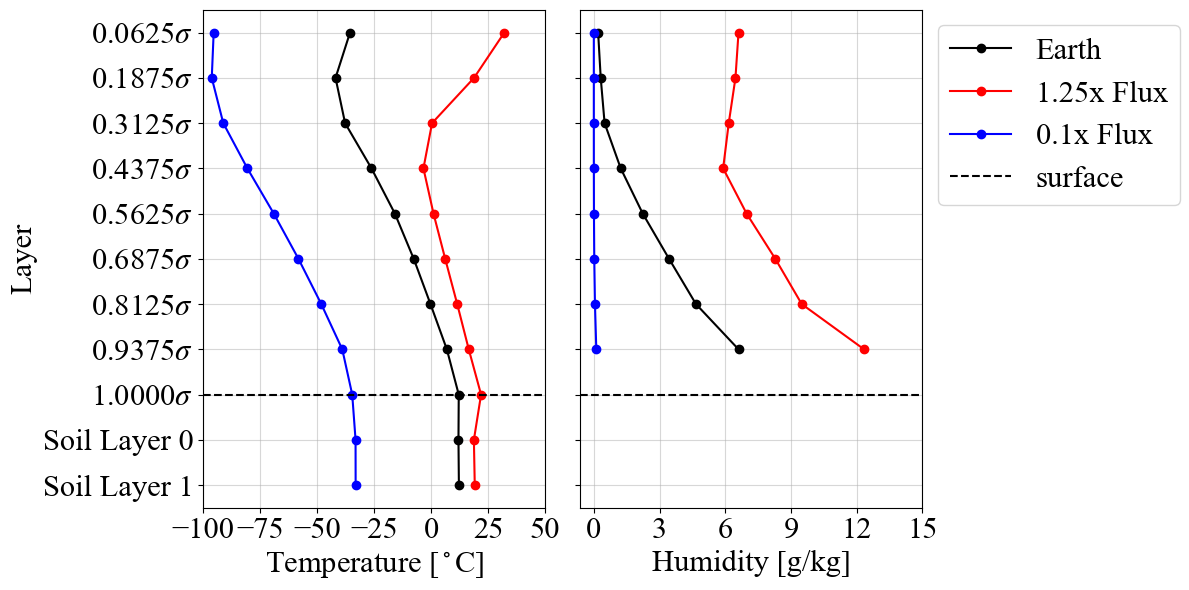

In [5]:
import matplotlib.pyplot as plt
import matplotlib as mpl

# Global Times New Roman
mpl.rcParams['font.family'] = 'Times New Roman'
mpl.rcParams['mathtext.fontset'] = 'stix'

fig, (ax1, ax2) = plt.subplots(
    ncols=2, 
    figsize=(12, 6), 
    sharey=True
)

y_pos = list(range(n_layers))

ax1.plot(vals_earth, y_pos, marker='o', label="Earth", color="black")
ax1.plot(vals_hot, y_pos, marker='o', label="1.25x Flux", color="red")
ax1.plot(vals_snow, y_pos, marker='o', label="0.1x Flux", color="blue")

ax1.set_xlabel("Temperature [$^\\circ$C]", size=22)
ax1.set_ylabel("Layer", size=22)
ax1.set_yticks(y_pos)
ax1.set_xlim(-100,50)
ax1.set_yticklabels(layer_labels, size=22)
ax1.set_xticks([-100,-75, -50, -25, 0, 25,50])
ax1.tick_params(axis='x', labelsize=22)
ax1.invert_yaxis()
ax1.grid(True, alpha=0.5)
ax1.axhline(y_pos[8], linestyle="--", color="black", label="surface")

y_pos_h = list(range(n_layers_humid))
vals_earth_humid2 = np.array(vals_earth_humid) * 1000
vals_hot_humid2 = np.array(vals_hot_humid) * 1000
vals_snow_humid2 = np.array(vals_snow_humid) * 1000
ax2.plot(vals_earth_humid2, y_pos_h, marker='o', label="Earth", color="black")
ax2.plot(vals_hot_humid2, y_pos_h, marker='o', label="1.25x Flux", color="red")
ax2.plot(vals_snow_humid2, y_pos_h, marker='o', label="0.1x Flux", color="blue")

ax2.set_xlabel("Humidity [g/kg]", size=22)
# ax2.set_xticks([0, 0.01])
ax2.tick_params(axis='x', labelsize=22)
ax2.set_xticks([0,3,6,9,12,15])
ax2.grid(True, alpha=0.5)
ax2.axhline(8, linestyle="--", color="black", label="surface")

ax2.legend(fontsize=22, bbox_to_anchor=(1, 1))
plt.tight_layout()
# plt.savefig("1.25flux_temphumid.png", dpi=300, bbox_inches='tight')
plt.show()

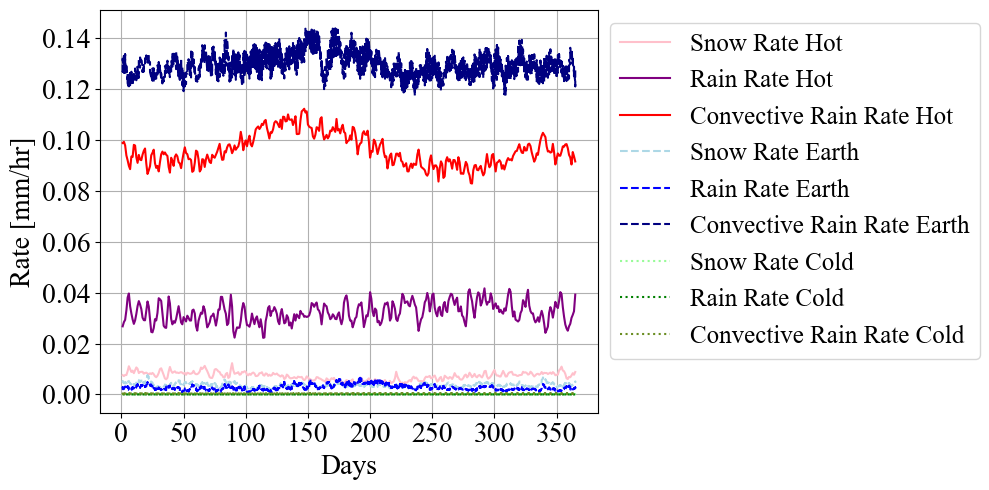

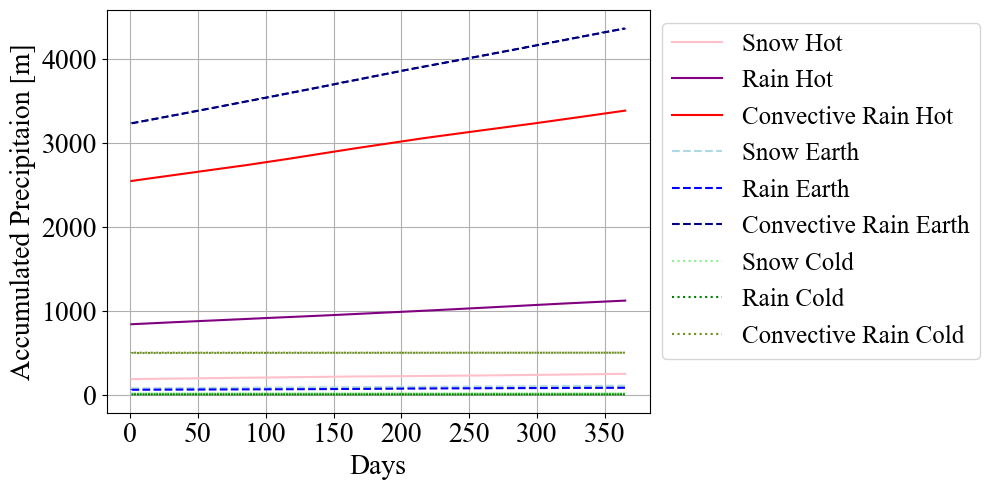

In [36]:
# Snow melt (smelt), snow depth (sd), accumulated snow (snow_cond), snow rate (snow_cond_rate)
# convective rain rate (rain_conv_rate), large-scale rain rate (rain_cond_rate), accumulated covective rain (rain_conv), accumulated large-scale rain (rain_cond)

snow_rate = WholeGlobeParam.globalparam_timeseries(ds_crop["snow_cond_rate"])
rain_rate = WholeGlobeParam.globalparam_timeseries(ds_crop["rain_cond_rate"])
convective_rain_rate = WholeGlobeParam.globalparam_timeseries(ds_crop["rain_conv_rate"])
snow = WholeGlobeParam.globalparam_timeseries(ds_crop["snow_cond"])
rain = WholeGlobeParam.globalparam_timeseries(ds_crop["rain_cond"])
convective_rain = WholeGlobeParam.globalparam_timeseries(ds_crop["rain_conv"])

snow_rate_earth = WholeGlobeParam.globalparam_timeseries(earth_crop["snow_cond_rate"])
rain_rate_earth = WholeGlobeParam.globalparam_timeseries(earth_crop["rain_cond_rate"])
convective_rain_rate_earth = WholeGlobeParam.globalparam_timeseries(earth_crop["rain_conv_rate"])
snow_earth = WholeGlobeParam.globalparam_timeseries(earth_crop["snow_cond"])
rain_earth = WholeGlobeParam.globalparam_timeseries(earth_crop["rain_cond"])
convective_rain_earth = WholeGlobeParam.globalparam_timeseries(earth_crop["rain_conv"])
times_earth = earth_crop.time.dt.dayofyear.values

snow_rate_cold = WholeGlobeParam.globalparam_timeseries(snow_crop["snow_cond_rate"])
rain_rate_cold = WholeGlobeParam.globalparam_timeseries(snow_crop["rain_cond_rate"])
convective_rain_rate_cold = WholeGlobeParam.globalparam_timeseries(snow_crop["rain_conv_rate"])
snow_cold = WholeGlobeParam.globalparam_timeseries(snow_crop["snow_cond"])
rain_cold = WholeGlobeParam.globalparam_timeseries(snow_crop["rain_cond"])
convective_rain_cold = WholeGlobeParam.globalparam_timeseries(snow_crop["rain_conv"])
times_cold = snow_crop.time.dt.dayofyear.values


fig = plt.figure(figsize=(10, 5))
plt.plot(times, snow_rate, color='pink', label="Snow Rate Hot")
plt.plot(times, rain_rate, color='purple', label="Rain Rate Hot")
plt.plot(times, convective_rain_rate, color='red', label="Convective Rain Rate Hot")
plt.plot(times_earth, snow_rate_earth, color='lightblue', label="Snow Rate Earth", linestyle="--")
plt.plot(times_earth, rain_rate_earth, color='blue', label="Rain Rate Earth", linestyle="--")
plt.plot(times_earth, convective_rain_rate_earth, color='navy', label="Convective Rain Rate Earth", linestyle="--")
plt.plot(times_cold, snow_rate_cold, color='palegreen', label="Snow Rate Cold", linestyle=":")
plt.plot(times_cold, rain_rate_cold, color='green', label="Rain Rate Cold", linestyle=":")
plt.plot(times_cold, convective_rain_rate_cold, color='olivedrab', label="Convective Rain Rate Cold", linestyle=":")
plt.ylabel("Rate [mm/hr]", size=20)
plt.xlabel('Days', size=20)
plt.xticks(size=20)
plt.yticks(size=20)
plt.grid(True)
plt.legend(fontsize=18,bbox_to_anchor = (1,1))
plt.tight_layout()
plt.show()

fig = plt.figure(figsize=(10, 5))
plt.plot(times, snow, color='pink', label="Snow Hot")
plt.plot(times, rain, color='purple', label="Rain Hot")
plt.plot(times, convective_rain, color='red', label="Convective Rain Hot")
plt.plot(times_earth, snow_earth, color='lightblue', label="Snow Earth", linestyle="--")
plt.plot(times_earth, rain_earth, color='blue', label="Rain Earth", linestyle="--")
plt.plot(times_earth, convective_rain_earth, color='navy', label="Convective Rain Earth", linestyle="--")
plt.plot(times_cold, snow_cold, color='lightgreen', label="Snow Cold", linestyle=":")
plt.plot(times_cold, rain_cold, color='green', label="Rain Cold", linestyle=":")
plt.plot(times_cold, convective_rain_cold, color='olivedrab', label="Convective Rain Cold", linestyle=":")
plt.ylabel("Accumulated Precipitaion [m]", size=20)
plt.xlabel('Days', size=20)
plt.xticks(size=20)
plt.yticks(size=20)
plt.grid(True)
plt.legend(fontsize=18,bbox_to_anchor=(1,1))
plt.tight_layout()
plt.show()


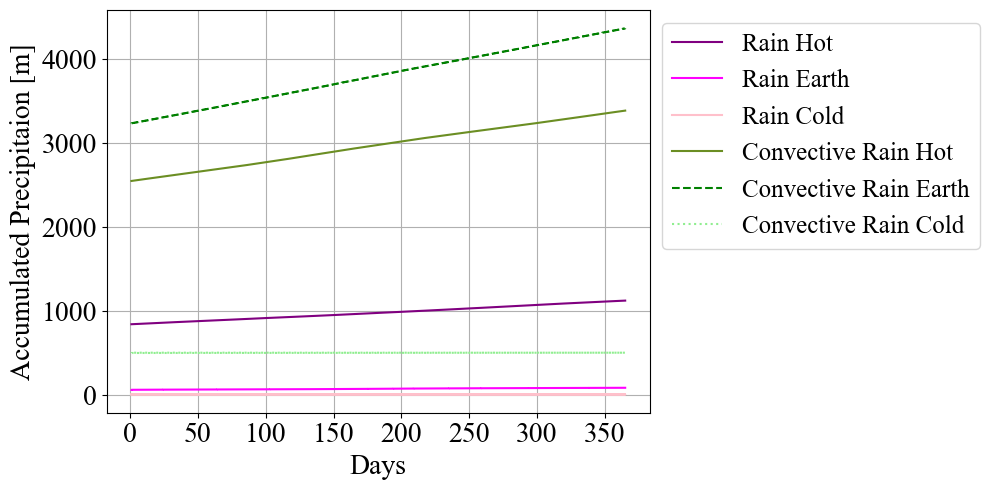

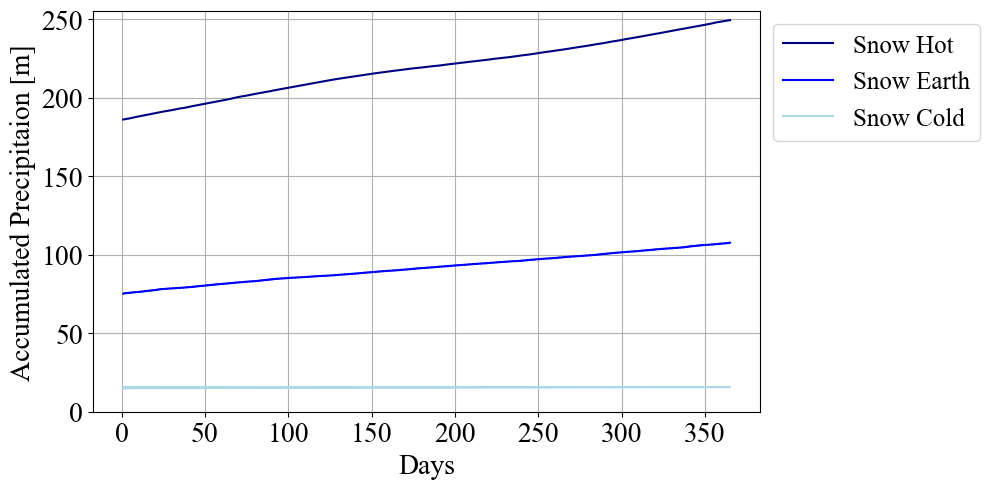

In [44]:
fig = plt.figure(figsize=(10, 5))

plt.plot(times, rain, color='purple', label="Rain Hot")
plt.plot(times_earth, rain_earth, color='magenta', label="Rain Earth")
plt.plot(times_cold, rain_cold, color='pink', label="Rain Cold")

plt.plot(times, convective_rain, color='olivedrab', label="Convective Rain Hot")
plt.plot(times_earth, convective_rain_earth, color='green', label="Convective Rain Earth", linestyle="--")
plt.plot(times_cold, convective_rain_cold, color="lightgreen", label="Convective Rain Cold", linestyle=":")

plt.ylabel("Accumulated Precipitaion [m]", size=20)
plt.xlabel('Days', size=20)
plt.xticks(size=20)
plt.yticks(size=20)
plt.grid(True)
plt.legend(fontsize=18,bbox_to_anchor=(1,1))
plt.tight_layout()
plt.show()

fig = plt.figure(figsize=(10, 5))
plt.plot(times, snow, color='navy', label="Snow Hot")
plt.plot(times_earth, snow_earth, color='blue', label="Snow Earth")
plt.plot(times_cold, snow_cold, color='lightblue', label="Snow Cold")
plt.ylabel("Accumulated Precipitaion [m]", size=20)
plt.xlabel('Days', size=20)
plt.ylim(0,255)
plt.xticks(size=20)
plt.yticks(size=20)
plt.grid(True)
plt.legend(fontsize=18,bbox_to_anchor=(1,1))
plt.tight_layout()
plt.show()